# Regime classification 

Using only information available today, can we predict which volatility regime the next five trading days will fall into ?

In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from market_risk.modelling.dataset import TEST_YEARS, load_model_dataset, create_walk_forward_fold, prepare_train_test
from market_risk.evaluation.regimes import get_regime_threshold, classify_regime

In [ ]:
# Load daatset
df = load_model_dataset()
df.head()

,date,sp500,vix,treasury_10y,treasury_2y,high_yield_spread,return_1d,return_5d,volatility_5d,volatility_10d,volatility_20d,vix_change_1d,vix_change_5d,vix_vs_realized_vol,yield_curve,treasury_10y_change_5d,treasury_2y_change_5d,target_volatility_5d
0,2016-08-08,2180.89,11.50,1.59,0.74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.85,NaN,NaN,0.099270
1,2016-08-09,2181.74,11.66,1.55,0.71,NaN,0.000390,NaN,NaN,NaN,NaN,0.16,NaN,NaN,0.84,NaN,NaN,0.131997
2,2016-08-10,2175.49,12.05,1.50,0.69,NaN,-0.002869,NaN,NaN,NaN,NaN,0.39,NaN,NaN,0.81,NaN,NaN,0.127387
3,2016-08-11,2185.79,11.68,1.57,0.76,NaN,0.004723,NaN,NaN,NaN,NaN,-0.37,NaN,NaN,0.81,NaN,NaN,0.108727
4,2016-08-12,2184.05,11.55,1.51,0.71,NaN,-0.000796,NaN,NaN,NaN,NaN,-0.13,NaN,NaN,0.80,NaN,NaN,0.110387


## 1. Manual check 2025

We start with 2025 because we alreafy know it contains an interesting stress episode, as shown in `01_data_exploratory.ipynb`.

In [3]:
train, test = create_walk_forward_fold(df, 2025)
X_train, y_train, X_test, y_test = prepare_train_test(train, test)

# calculate the thresholds
elevated_threshold, stress_threshold = get_regime_threshold(y_train)
print(f"Elevated threshold: {elevated_threshold:.5f}")
print(f"Stress threshold: {stress_threshold:.5f}")

Elevated threshold: 0.35829
Stress threshold: 0.57310


In [20]:
train.head()

,date,sp500,vix,treasury_10y,treasury_2y,high_yield_spread,return_1d,return_5d,volatility_5d,volatility_10d,volatility_20d,vix_change_1d,vix_change_5d,vix_vs_realized_vol,yield_curve,treasury_10y_change_5d,treasury_2y_change_5d,target_volatility_5d
0,2016-08-08,2180.89,11.50,1.59,0.74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.85,NaN,NaN,0.099270
1,2016-08-09,2181.74,11.66,1.55,0.71,NaN,0.000390,NaN,NaN,NaN,NaN,0.16,NaN,NaN,0.84,NaN,NaN,0.131997
2,2016-08-10,2175.49,12.05,1.50,0.69,NaN,-0.002869,NaN,NaN,NaN,NaN,0.39,NaN,NaN,0.81,NaN,NaN,0.127387
3,2016-08-11,2185.79,11.68,1.57,0.76,NaN,0.004723,NaN,NaN,NaN,NaN,-0.37,NaN,NaN,0.81,NaN,NaN,0.108727
4,2016-08-12,2184.05,11.55,1.51,0.71,NaN,-0.000796,NaN,NaN,NaN,NaN,-0.13,NaN,NaN,0.80,NaN,NaN,0.110387


We get the same values as in `regimes.py`, that is a good consistency check.

### Create training and test labels

In [46]:
y_train_class = pd.DataFrame(
    {
        "date": train.loc[y_train.index, "date"],
        "regime": y_train.apply(lambda x: classify_regime(x, elevated_threshold, stress_threshold)),
    }
)

y_test_class = pd.DataFrame(
    {
        "date": test.loc[y_test.index, "date"],
        "regime": y_test.apply(lambda x: classify_regime(x, elevated_threshold, stress_threshold)),
    }
)

y_train_class["date"] = pd.to_datetime(y_train_class["date"])
y_test_class["date"] = pd.to_datetime(y_test_class["date"])

In [26]:
y_train_class.head()

,date,label
20,2016-09-06,Elevated
21,2016-09-07,Elevated
22,2016-09-08,Elevated
23,2016-09-09,Elevated
24,2016-09-12,Normal


In [27]:
y_test_class.head()

,date,label
2114,2025-01-02,Elevated
2115,2025-01-03,Normal
2116,2025-01-06,Normal
2117,2025-01-07,Elevated
2118,2025-01-08,Elevated


### Check training proportions

In [47]:
y_train_class["regime"].value_counts(normalize=True)

regime
Normal      0.699856
Elevated    0.200096
Stress      0.100048
Name: proportion, dtype: float64

The training distribution roughly reflect : 
70% Normal
20% Elevated
10% Stress

because we initially defined the thresholds as :
70th percentile and 90th percentile

### Inspect test distributions

In [48]:
y_test_class["regime"].value_counts(normalize=True)

regime
Normal      0.744
Elevated    0.188
Stress      0.068
Name: proportion, dtype: float64

Unlike the training distribution, we do not expect 70/20/10 here.

The thresholds came from historical training conditions. If 2025 was unusually volatile, for example, it could naturally contain proportionally more Elevated or Stress observations.

We must not adjust the thresholds to force the test set into a particular distribution.

### Inspect labels alongside the actual target

In [42]:
regime_check = pd.DataFrame(
    {
        "date": y_test_class["date"],
        "target_volatility_5d": y_test,
        "regime": y_test_class["label"]
    }
)

regime_check["date"] = pd.to_datetime(regime_check["date"])
regime_check.sort_values(by="target_volatility_5d", ascending=False).head()

,date,target_volatility_5d,regime
2175,2025-04-02,1.929532,Stress
2176,2025-04-03,1.848132,Stress
2178,2025-04-07,1.598282,Stress
2177,2025-04-04,1.593768,Stress
2179,2025-04-08,1.578654,Stress


### Check specifically April 2025

In [44]:
regime_check.loc[regime_check["date"].between("2025-04-01", "2025-04-30"), ["date", "regime"]]


,date,regime
2174,2025-04-01,Stress
2175,2025-04-02,Stress
2176,2025-04-03,Stress
2177,2025-04-04,Stress
2178,2025-04-07,Stress
2179,2025-04-08,Stress
2180,2025-04-09,Stress
2181,2025-04-10,Elevated
2182,2025-04-11,Elevated
2183,2025-04-14,Stress


We see the major forward-volatility observations around the April shock classified as Stress.

Regression question:
How high will future volatility be?

Classification question:
Will future volatility enter Normal,
Elevated, or Stress conditions?

## 2. Dummy classifier

In [145]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier

In [ ]:
dummy_model = DummyClassifier(strategy="most_frequent")

dummy_model.fit(X_train, y_train_class)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [77]:
# Generate predictions
y_pred_dummy = dummy_model.predict(X_test)


In [78]:
# verify that the number of prediction matches
len(y_pred_dummy), len(X_test)

(250, 250)

In [81]:
# Verify the model
y_pred_dummy = pd.DataFrame(y_pred_dummy, columns=["date", "regime"])
y_pred_dummy["regime"].value_counts()

regime
Normal    250
Name: count, dtype: int64

This confirms that the dummy model is simply predicting the majority class.

### Accuracy

`y_test_class` and `y_pred_dummy` : dataframes with columns "date" and "regime"

In [85]:
dummy_accuracy = accuracy_score(y_test_class["regime"], y_pred_dummy["regime"])

dummy_accuracy

0.744

The accuracy score should correspond to the proportion of Normal regime in y_test (= 0.744)

### Macro F1

Why average="macro" : sklearn calculates F1 separately for the 3 regimes, and then gives each ca=lass equql weight. SO id the classifier completely fails to detect Elevate and Stress, macro F1 will punish if heavilly.

In [86]:
dummy_macro_f1 = f1_score(y_test_class["regime"], y_pred_dummy["regime"], average="macro")
dummy_macro_f1

0.28440366972477066

### Classification report 

In [89]:
CLASS_LABELS = ["Normal", "Elevated", "Stress"]

print(
    classification_report(
        y_test_class["regime"], 
        y_pred_dummy["regime"],
        labels=CLASS_LABELS,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

      Normal       0.74      1.00      0.85       186
    Elevated       0.00      0.00      0.00        47
      Stress       0.00      0.00      0.00        17

    accuracy                           0.74       250
   macro avg       0.25      0.33      0.28       250
weighted avg       0.55      0.74      0.63       250



### Confusion matrix : 
- columns : predicted 
- rows : actual

In [91]:
dummy_confusion = confusion_matrix(
    y_test_class["regime"],
    y_pred_dummy["regime"],
    labels=CLASS_LABELS,
)

dummy_confusion

array([[186,   0,   0],
       [ 47,   0,   0],
       [ 17,   0,   0]])

In [94]:
stress_recall = (
    (
        (y_test_class["regime"] == "Stress")
        & (y_pred_dummy["regime"] == "Stress")
    ).sum()
    / (y_test_class["regime"] == "Stress").sum()
)

stress_recall

np.float64(0.0)

In [ ]:
dummy_results = pd.DataFrame(
    {
        "metric": [
            "Accuracy",
            "Macro F1",
            "Stress Recall",
        ],
        "value": [
            dummy_accuracy,
            dummy_macro_f1,
            stress_recall,
        ],
    }
)

dummy_results

,metric,value
0,Accuracy,0.744000
1,Macro F1,0.284404
2,Stress Recall,0.000000


## 3. Logistic regression 

In [125]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score
from sklearn.metrics import ConfusionMatrixDisplay

In [101]:
# Create the model

logistic_model = Pipeline(
    steps=[("scaler", StandardScaler()), 
           ("classifier", LogisticRegression(
               class_weight="balanced",         # gives more importance to mistakes on the rarer Elevated and Stress classes
               max_iter=1000,
               random_state=42,
           )
        )
    ]
)

In [ ]:
# fit the model
logistic_model.fit(X_train, y_train_class["regime"])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may n

In [ ]:
# predictions : returns the final class label for each observation
y_pred_logistic = logistic_model.predict(X_test)

In [114]:
y_test_class.drop(columns=["date"])

2114    Elevated
2115      Normal
2116      Normal
2117    Elevated
2118    Elevated
          ...   
2359      Normal
2360      Normal
2361      Normal
2362      Normal
2363      Normal
Name: regime, Length: 250, dtype: str

`y_pred_dummy` was a DataFrame with the date column, because it was useful to extract only 2025 or another period od time. But since it's inconvinient here I just kept the prediction series.

Thus, I also removed the time column from `y_test_class` in order to stay consistant.

In [115]:
# proba : returns one probability per class
y_prob_logistic = logistic_model.predict_proba(X_test)

### Metrics

In [118]:
logistic_accuracy = accuracy_score(y_pred=y_pred_logistic, y_true=y_test_class)
logistic_macro_f1 = f1_score(y_test_class, y_pred_logistic, average="macro")

print(f"Logistic accuracy: {logistic_accuracy:.5f}")
print(f"Logistic macro F1: {logistic_macro_f1:.5f}")

Logistic accuracy: 0.68400
Logistic macro F1: 0.53385


### Classification report

In [117]:
print(
    classification_report(
        y_test_class,
        y_pred_logistic,
        labels=CLASS_LABELS,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

      Normal       0.90      0.76      0.82       186
    Elevated       0.33      0.40      0.36        47
      Stress       0.31      0.65      0.42        17

    accuracy                           0.68       250
   macro avg       0.51      0.60      0.53       250
weighted avg       0.75      0.68      0.71       250



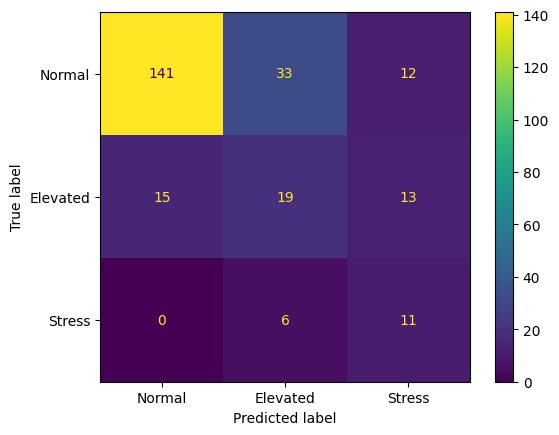

In [ ]:
logistic_confusion = confusion_matrix(
    y_test_class,
    y_pred_logistic,
    labels=CLASS_LABELS,
)

ConfusionMatrixDisplay(
    confusion_matrix=logistic_confusion,
    display_labels=CLASS_LABELS,
).plot()

In [122]:
stress_recall_logistic = recall_score(
    y_test_class,
    y_pred_logistic,
    labels=["Stress"],
    average=None,
)[0]

### Comparison Logistic regression and Dummy

In [123]:
comparison_2025 = pd.DataFrame(
    {
        "model": [
            "Dummy",
            "Logistic Regression",
        ],
        "accuracy": [
            dummy_accuracy,
            logistic_accuracy,
        ],
        "macro_f1": [
            dummy_macro_f1,
            logistic_macro_f1,
        ],
        "stress_recall": [
            0.0,
            stress_recall_logistic,
        ],
    }
)

comparison_2025

,model,accuracy,macro_f1,stress_recall
0,Dummy,0.744,0.284404,0.000000
1,Logistic Regression,0.684,0.533854,0.647059


### Results analysis

- The Dummy model has higher accuracy because it predicts the dominant Normal class all the time. But it detects none of the Stress observations
- Macro F1 improves substantially
- Logistic Regression correctly identifies roughly 65% of the actual future Stress observations in the 2025 fold
- No Stress observations classified as Normal. Cost → many false Stress warnings


What is Stress precision?

How well does it detect Elevated?

Where are the remaining Stress observations being misclassified?
- Stress → Elevated?
- Stress → Normal?

### Walk-forward evaluation : 2022-2025

In [128]:
# Logistic model function : because every fold should start with a new unfitted model

def create_logistic_model():
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42,
            ))
        ]
    )

Walk-forward loop

In [ ]:
fold_metrics = [] # store one summary row per year × model
all_predictions = [] # store every individual out-of-sample observation : for now only Logistic regression

for test_year in TEST_YEARS:
    
    # create leakage-safe fold
    train, test = create_walk_forward_fold(df, test_year)
    X_train, y_train, X_test, y_test = prepare_train_test(train, test)
    
    # Regime thresholds (from TRAIN !)
    elevated_threshold, stress_threshold = get_regime_threshold(y_train)
    
    # create classification labels
    y_train_class = y_train.apply(lambda x: classify_regime(x, elevated_threshold, stress_threshold))
    y_test_class = y_test.apply(lambda x: classify_regime(x, elevated_threshold, stress_threshold))

    # Models
    models = {
        "Dummy": DummyClassifier(strategy="most_frequent"),
        "Logistic Regression": create_logistic_model(),
    }

    # Fit and evaluate
    for model_name, model in models.items():
        model.fit(X_train, y_train_class)
        y_pred = model.predict(X_test)

        # metrics
        accuracy = accuracy_score(y_pred=y_pred, y_true=y_test_class)
        macro_f1 = f1_score(y_pred=y_pred, y_true=y_test_class, labels=CLASS_LABELS, average="macro", zero_division=0)
        stress_precision = precision_score(y_test_class, y_pred, labels=["Stress"], average=None, zero_division=0)[0]
        stress_recall = recall_score(y_test_class, y_pred, labels=["Stress"], average=None, zero_division=0)[0]
        stress_f1 = f1_score(y_test_class, y_pred, labels=["Stress"], average=None, zero_division=0)[0]
        
        # predictions for LR
        if model_name == "Logistic Regression":
            prediction_df = pd.DataFrame(
                {
                    "date": test.loc[y_test.index, "date"].values,
                    "year": test_year,
                    "actual_regime": y_test_class.values,
                    "predicted_regime": y_pred,
                }
            )

            all_predictions.append(prediction_df)

        # save metrics
        fold_metrics.append(
            {
                "year": test_year,
                "model": model_name,
                "accuracy": accuracy,
                "macro_f1": macro_f1,
                "stress_precision": stress_precision,
                "stress_recall": stress_recall,
                "stress_f1": stress_f1,
            }
        )

fold_metrics_df = pd.DataFrame(fold_metrics)
fold_metrics_df

,year,model,accuracy,macro_f1,stress_precision,stress_recall,stress_f1
0,2022,Dummy,0.103586,0.062575,0.000000,0.000000,0.000000
1,2022,Logistic Regression,0.430279,0.278289,0.389908,1.000000,0.561056
2,2023,Dummy,0.840000,0.304348,0.000000,0.000000,0.000000
3,2023,Logistic Regression,0.216000,0.154759,0.000000,0.000000,0.000000
4,2024,Dummy,0.853175,0.306924,0.000000,0.000000,0.000000
5,2024,Logistic Regression,0.730159,0.373716,0.000000,0.000000,0.000000
6,2025,Dummy,0.744000,0.284404,0.000000,0.000000,0.000000
7,2025,Logistic Regression,0.684000,0.533854,0.305556,0.647059,0.415094


In [160]:
all_predictions_df = pd.concat(
    all_predictions,
    ignore_index=True,
)

all_predictions_df.head()

,date,year,actual_regime,predicted_regime
0,2022-01-03,2022,Elevated,Normal
1,2022-01-04,2022,Elevated,Normal
2,2022-01-05,2022,Normal,Elevated
3,2022-01-06,2022,Normal,Elevated
4,2022-01-07,2022,Normal,Elevated


#### Interpretation

- 2022 is the most stressed test year: only 26 observations are Normal, versus 140 Elevated and 85 Stress. Logistic Regression captures all 85 Stress observations, though with moderate precision, meaning it also produces false Stress signals.
- 2023 and 2024 are much calmer: 2023 has no Stress observations at all, while 2024 has only 5. The zero Stress recall in 2023 is therefore not a failure, whereas in 2024 it means the model missed all 5 Stress cases.
- 2025 is more balanced: with 186 Normal, 47 Elevated and 17 Stress observations, Logistic Regression detects 11 of the 17 Stress cases, giving a Stress recall of about 64.7%.

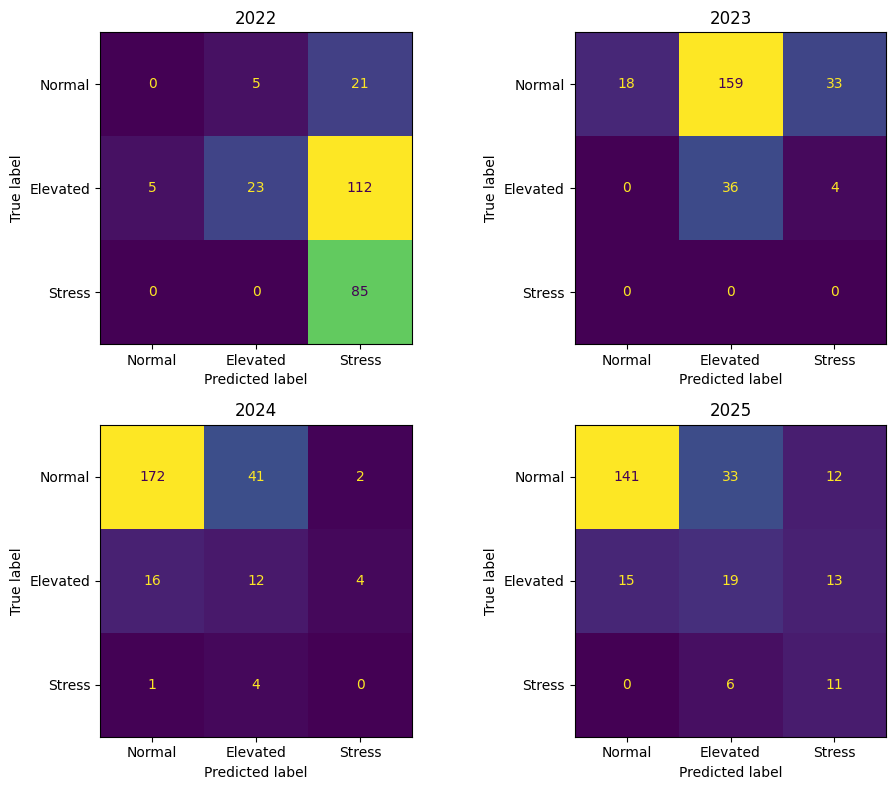

In [167]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, test_year in zip(axes, TEST_YEARS):

    year_predictions = all_predictions_df.loc[
        all_predictions_df["year"] == test_year
    ]

    cm = confusion_matrix(
        year_predictions["actual_regime"],
        year_predictions["predicted_regime"],
        labels=CLASS_LABELS,
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_LABELS,
    )

    display.plot(ax=ax, colorbar=False)
    ax.set_title(f"{test_year}")

plt.tight_layout()
plt.show()

- 2022: the classifier is extremely stress-sensitive. It correctly identifies all 85 Stress observations, but also classifies most Elevated observations (112/140) and many Normal observations (21/26) as Stress. This explains the perfect Stress recall but relatively low Stress precision.
- 2023: the model shifts strongly toward predicting Elevated. Of 210 actual Normal observations, 159 are classified as Elevated. There are no actual Stress observations, although the model still produces 37 Stress predictions. This explains the very low overall accuracy.
- 2024: performance is much better for Normal conditions (172/215 correctly classified), but the model struggles with the minority regimes. All 5 Stress observations are missed: 4 are classified as Elevated and 1 as Normal.
- 2025: the predictions are substantially more balanced. The model correctly detects 11/17 Stress observations, while the other 6 are classified as Elevated and none as Normal. Elevated remains the most difficult intermediate regime.

#### Check

In [ ]:
regime_counts = []

for test_year in TEST_YEARS:

    train, test = create_walk_forward_fold(df, test_year)
    X_train, y_train, X_test, y_test = prepare_train_test(train, test)
    elevated_threshold, stress_threshold = get_regime_threshold(y_train)

    y_test_class = y_test.apply(
        lambda x: classify_regime(x, elevated_threshold, stress_threshold)
    )

    counts = (y_test_class
        .value_counts()
        .reindex(
            ["Normal", "Elevated", "Stress"],
            fill_value=0,
        )
    )

    regime_counts.append(
        {
            "year": test_year,
            "Normal": counts["Normal"],
            "Elevated": counts["Elevated"],
            "Stress": counts["Stress"],
        }
    )

regime_counts_df = pd.DataFrame(regime_counts)

regime_counts_df

,year,Normal,Elevated,Stress
0,2022,26,140,85
1,2023,210,40,0
2,2024,215,32,5
3,2025,186,47,17


In [161]:
all_predictions_df["year"].value_counts().sort_index()

year
2022    251
2023    250
2024    252
2025    250
Name: count, dtype: int64

## 4. Pooled 2022–2025 evaluation

In [171]:
logistic_predictions = all_predictions_df.copy()

### Metrics

In [179]:
# Calculate pooled metrics

pooled_accuracy = accuracy_score(logistic_predictions["actual_regime"], logistic_predictions["predicted_regime"])
pooled_macro_f1 = f1_score(logistic_predictions["actual_regime"], logistic_predictions["predicted_regime"], labels=CLASS_LABELS, average="macro", zero_division=0)
pooled_stress_precision = precision_score(logistic_predictions["actual_regime"], logistic_predictions["predicted_regime"], labels=["Stress"], average=None, zero_division=0)[0]
pooled_stress_f1 = f1_score(logistic_predictions["actual_regime"], logistic_predictions["predicted_regime"], average=None, labels=CLASS_LABELS, zero_division=0)[0]
pooled_stress_recall = recall_score(logistic_predictions["actual_regime"], logistic_predictions["predicted_regime"], labels=CLASS_LABELS, average=None, zero_division=0)[0]


In [180]:
pd.DataFrame(
    {
        "accuracy": [pooled_accuracy],
        "macro_f1": [macro_f1],
        "stress_precision": [pooled_stress_precision],
        "stress_recall": [pooled_stress_recall],
        "stress_f1": [pooled_stress_f1],
    }
)

,accuracy,macro_f1,stress_precision,stress_recall,stress_f1
0,0.515454,0.533854,0.323232,0.519623,0.658706


### Pooled classification report

In [181]:
print(classification_report(logistic_predictions["actual_regime"], logistic_predictions["predicted_regime"], labels=CLASS_LABELS, zero_division=0))

              precision    recall  f1-score   support

      Normal       0.90      0.52      0.66       637
    Elevated       0.27      0.35      0.30       259
      Stress       0.32      0.90      0.48       107

    accuracy                           0.52      1003
   macro avg       0.50      0.59      0.48      1003
weighted avg       0.67      0.52      0.55      1003



### Confusion matrix

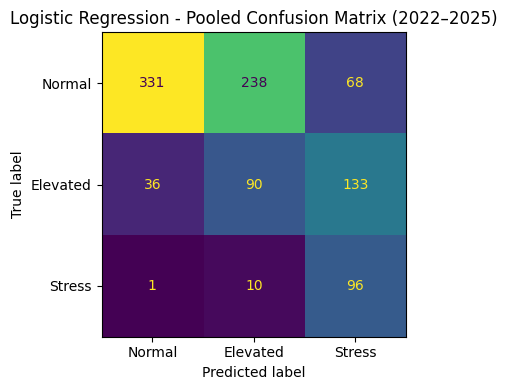

In [182]:
pooled_cm = confusion_matrix(logistic_predictions["actual_regime"], logistic_predictions["predicted_regime"], labels=CLASS_LABELS)
display = ConfusionMatrixDisplay(confusion_matrix=pooled_cm, display_labels=CLASS_LABELS)

fig, ax = plt.subplots(figsize=(5, 4))
display.plot(ax=ax, colorbar=False)

ax.set_title("Logistic Regression - Pooled Confusion Matrix (2022–2025)")

plt.tight_layout()
plt.show()

- Normal: 331/637 are correctly classified. A large number are pushed into Elevated (238), showing the classifier is relatively cautious and often predicts more risk than actually occurs.
- Elevated: only 90/259 are correctly classified. The model frequently predicts Stress instead (133), confirming that Elevated is the hardest regime to separate cleanly.
- Stress: 96/107 are correctly identified. Only 1 Stress observation is classified as Normal, while 10 are classified as Elevated. This is the strongest result: the model rarely completely misses future Stress.


This matches the classification report: Stress recall is excellent (~90%) but Stress precision is low (~32%).

## 5. LightGBM classifier

In [ ]:
from lightgbm import LGBMClassifier

In [188]:
# Create the model function

def create_lightgbm_classifier():
    model = LGBMClassifier(
        ojective="multiclass",
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        num_leaves=7,
        min_child_samples=20,
        reg_lambda=1.0,
        class_weight="balanced",
        random_state=42,
        verbosity=-1,
    )
    return model

## 6. Walk-foreward loop

In [189]:
fold_metrics = [] # store one summary row per year × model
all_predictions = [] # store every individual out-of-sample observation 

for test_year in TEST_YEARS:
    
    # create leakage-safe fold
    train, test = create_walk_forward_fold(df, test_year)
    X_train, y_train, X_test, y_test = prepare_train_test(train, test)
    
    # Regime thresholds (from TRAIN !)
    elevated_threshold, stress_threshold = get_regime_threshold(y_train)
    
    # create classification labels
    y_train_class = y_train.apply(lambda x: classify_regime(x, elevated_threshold, stress_threshold))
    y_test_class = y_test.apply(lambda x: classify_regime(x, elevated_threshold, stress_threshold))

    # Models
    models = {
        "Dummy": DummyClassifier(strategy="most_frequent"),
        "Logistic Regression": create_logistic_model(),
        "LightGBM": create_lightgbm_classifier(),
    }

    # Fit and evaluate
    for model_name, model in models.items():
        model.fit(X_train, y_train_class)
        y_pred = model.predict(X_test)

        # metrics
        accuracy = accuracy_score(y_pred=y_pred, y_true=y_test_class)
        macro_f1 = f1_score(y_pred=y_pred, y_true=y_test_class, labels=CLASS_LABELS, average="macro", zero_division=0)
        stress_precision = precision_score(y_test_class, y_pred, labels=["Stress"], average=None, zero_division=0)[0]
        stress_recall = recall_score(y_test_class, y_pred, labels=["Stress"], average=None, zero_division=0)[0]
        stress_f1 = f1_score(y_test_class, y_pred, labels=["Stress"], average=None, zero_division=0)[0]
        
        # predictions for LR
        if model_name in ["Logistic Regression", "LightGBM"]:
            prediction_df = pd.DataFrame(
                {
                    "date": test.loc[y_test.index, "date"].values,
                    "year": test_year,
                    "model": model_name,
                    "actual_regime": y_test_class.values,
                    "predicted_regime": y_pred,
                }
            )

            all_predictions.append(prediction_df)

        # save metrics
        fold_metrics.append(
            {
                "year": test_year,
                "model": model_name,
                "accuracy": accuracy,
                "macro_f1": macro_f1,
                "stress_precision": stress_precision,
                "stress_recall": stress_recall,
                "stress_f1": stress_f1,
            }
        )

fold_metrics_df = pd.DataFrame(fold_metrics)
fold_metrics_df

c:\Users\luluc\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\luluc\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,year,model,accuracy,macro_f1,stress_precision,stress_recall,stress_f1
0,2022,Dummy,0.103586,0.062575,0.000000,0.000000,0.000000
1,2022,Logistic Regression,0.430279,0.278289,0.389908,1.000000,0.561056
2,2022,LightGBM,0.498008,0.349822,0.438202,0.917647,0.593156
3,2023,Dummy,0.840000,0.304348,0.000000,0.000000,0.000000
4,2023,Logistic Regression,0.216000,0.154759,0.000000,0.000000,0.000000
5,2023,LightGBM,0.308000,0.258149,0.000000,0.000000,0.000000
6,2024,Dummy,0.853175,0.306924,0.000000,0.000000,0.000000
7,2024,Logistic Regression,0.730159,0.373716,0.000000,0.000000,0.000000
8,2024,LightGBM,0.746032,0.390075,0.000000,0.000000,0.000000
9,2025,Dummy,0.744000,0.284404,0.000000,0.000000,0.000000


- 2022: LightGBM improves over Logistic Regression: Macro F1 rises from 0.278 → 0.350, while Stress recall remains very high at 91.8%. Stress precision also improves from 39.0% to 43.8%
- 2023–2024: LightGBM improves Macro F1 over Logistic Regression in both years. There is no Stress in 2023; in 2024, however, both models still fail to detect the 5 Stress observations
- 2025: LightGBM achieves the best Macro F1 (0.566) and better Stress precision/F1 than Logistic Regression, although Stress recall decreases slightly from 64.7% to 58.8%

In [191]:
all_predictions_df = pd.concat(
    all_predictions,
    ignore_index=True,
)

### Pooled classification report

In [196]:
# Logistic regression
logistic_predictions = all_predictions_df.loc[all_predictions_df["model"] == "Logistic Regression"]

print(
    classification_report(
        logistic_predictions["actual_regime"],
        logistic_predictions["predicted_regime"],
        labels=CLASS_LABELS,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

      Normal       0.90      0.52      0.66       637
    Elevated       0.27      0.35      0.30       259
      Stress       0.32      0.90      0.48       107

    accuracy                           0.52      1003
   macro avg       0.50      0.59      0.48      1003
weighted avg       0.67      0.52      0.55      1003



In [194]:
# LightGBM
lightgbm_predictions = all_predictions_df.loc[all_predictions_df["model"] == "LightGBM"]

print(
    classification_report(
        lightgbm_predictions["actual_regime"],
        lightgbm_predictions["predicted_regime"],
        labels=CLASS_LABELS,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

      Normal       0.91      0.55      0.69       637
    Elevated       0.39      0.45      0.42       259
      Stress       0.28      0.82      0.42       107

    accuracy                           0.55      1003
   macro avg       0.52      0.61      0.51      1003
weighted avg       0.71      0.55      0.59      1003



In [197]:
pooled_results = []

for model_name, predictions in {
    "Logistic Regression": logistic_predictions,
    "LightGBM": lightgbm_predictions,
}.items():

    pooled_results.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(
                predictions["actual_regime"],
                predictions["predicted_regime"],
            ),
            "macro_f1": f1_score(
                predictions["actual_regime"],
                predictions["predicted_regime"],
                labels=CLASS_LABELS,
                average="macro",
                zero_division=0,
            ),
            "stress_precision": precision_score(
                predictions["actual_regime"],
                predictions["predicted_regime"],
                labels=["Stress"],
                average=None,
                zero_division=0,
            )[0],
            "stress_recall": recall_score(
                predictions["actual_regime"],
                predictions["predicted_regime"],
                labels=["Stress"],
                average=None,
                zero_division=0,
            )[0],
            "stress_f1": f1_score(
                predictions["actual_regime"],
                predictions["predicted_regime"],
                labels=["Stress"],
                average=None,
                zero_division=0,
            )[0],
        }
    )

pooled_results_df = pd.DataFrame(pooled_results)

pooled_results_df

,model,accuracy,macro_f1,stress_precision,stress_recall,stress_f1
0,Logistic Regression,0.515454,0.478487,0.323232,0.897196,0.475248
1,LightGBM,0.554337,0.506225,0.278481,0.822430,0.416076


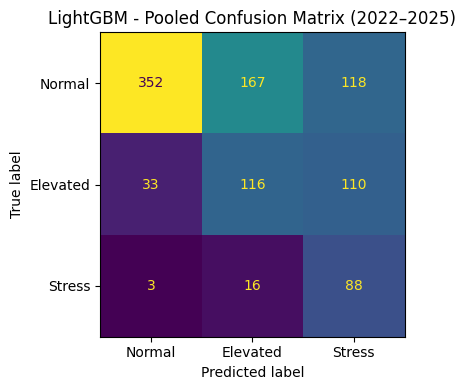

In [198]:
lightgbm_cm = confusion_matrix(
    lightgbm_predictions["actual_regime"],
    lightgbm_predictions["predicted_regime"],
    labels=CLASS_LABELS,
)

display = ConfusionMatrixDisplay(
    confusion_matrix=lightgbm_cm,
    display_labels=CLASS_LABELS,
)

fig, ax = plt.subplots(figsize=(5, 4))

display.plot(
    ax=ax,
    colorbar=False,
)

ax.set_title(
    "LightGBM - Pooled Confusion Matrix (2022–2025)"
)

plt.tight_layout()
plt.show()

- LightGBM is better overall: higher accuracy and higher Macro F1, so it separates the three regimes more effectively on average
- Logistic Regression is better specifically for Stress detection: it catches about 89.7% of Stress observations versus 82.2% for LightGBM, and also has better Stress precision and F1
- LightGBM's confusion matrix shows 88/107 Stress observations correctly detected, 16 classified as Elevated, and only 3 classified as Normal. So it still rarely completely misses a Stress regime
- LightGBM also handles the Elevated class better than Logistic Regression, which helps explain its stronger Macro F1


LightGBM is the stronger overall three-class regime classifier, while Logistic Regression is the stronger Stress-focused detector.